# Fractional Brownian Flow Matching

Train a configurable SSM or GRU velocity field to map Gaussian path noise into 1000-step fractional Brownian motion paths conditioned on the Hurst exponent.

In [1]:
import math
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

device

device(type='cuda')

In [2]:
@dataclass
class TrainConfig:
    n_steps: int = 512
    batch_size: int = 64
    train_steps: int = 10000000
    plot_every: int = 1000000
    eval_every: int = 5000
    eval_batch_size: int = 256
    eval_grid_size: int = 256
    eval_length_multiplier: int = 2
    # eval_grid_size: int = 128
    model_type: str = "causal_gdn2"
    hidden_size: int = 256
    res_conv_layers: int = 2
    res_conv_kernel_size: int = 5
    gdn2_num_heads: int = 4
    gdn2_num_v_heads: int = 0
    gdn2_head_dim: int = 0
    gdn2_expand_v: float = 1.0
    gdn2_mode: str = "chunk"
    gdn2_use_short_conv: bool = True
    gdn2_conv_size: int = 4
    precision: str = "bf16"
    log_every: int = 500
    profile_timing: bool = False
    timing_every: int = 500
    use_analytic_velocity: bool = True
    use_causal_velocity: bool = True
    aux_cov_dyn_weight: float = 0.2
    aux_cov_bias_corrected: bool = True
    aux_vario_weight: float = 0.1
    aux_grid_size: int = 256
    aux_lags: tuple = (1, 2, 4, 8, 16, 32)
    # aux_lags: tuple = (1, 2, 4, 8, 16, 32, 64, 128, 256)
    aux_vario_low_lag_power: float = 1.5
    aux_vario_relative_floor: float = 5e-2
    aux_cov_high_index_power: float = 2.0
    aux_weight_floor: float = 0.05
    lr: float = 1e-4
    lr_decay_steps: int = 500000
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    use_fused_optimizer: bool = True
    ode_steps: int = 128
    hurst_min: float = 0.15
    hurst_max: float = 0.85


cfg = TrainConfig()

amp_enabled = cfg.precision.lower() == "bf16" and device.type == "cuda" and torch.cuda.is_bf16_supported()
amp_dtype = torch.bfloat16 if amp_enabled else torch.float32


def autocast_context():
    return torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=amp_enabled)


def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()


_path_time_cache = {}
_arange_cache = {}
_identity_cache = {}
_subsampled_time_indices_cache = {}
_lags_cache = {}


def path_time_grid(n_steps, *, device, dtype):
    key = (int(n_steps), device.type, device.index, str(dtype))
    if key not in _path_time_cache:
        _path_time_cache[key] = torch.linspace(1 / n_steps, 1.0, n_steps, device=device, dtype=dtype).view(1, n_steps, 1)
    return _path_time_cache[key]


def arange_grid(n_steps, *, device, dtype=torch.float32):
    key = (int(n_steps), device.type, device.index, str(dtype))
    if key not in _arange_cache:
        _arange_cache[key] = torch.arange(n_steps, device=device, dtype=dtype)
    return _arange_cache[key]


def identity_matrix(size, *, device, dtype=torch.float32):
    key = (int(size), device.type, device.index, str(dtype))
    if key not in _identity_cache:
        _identity_cache[key] = torch.eye(size, device=device, dtype=dtype)
    return _identity_cache[key]


cfg.precision, amp_enabled

('bf16', True)

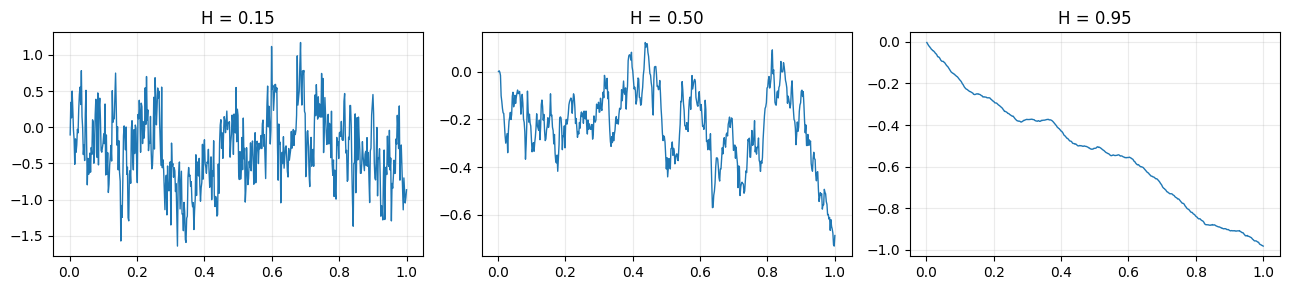

In [3]:
def _as_hurst_batch(hurst, batch_size, *, device, dtype):
    if hurst is None:
        return torch.empty(batch_size, device=device, dtype=dtype).uniform_(cfg.hurst_min, cfg.hurst_max)

    hurst = torch.as_tensor(hurst, device=device, dtype=dtype).flatten()
    if hurst.numel() == 1:
        return hurst.expand(batch_size)
    if hurst.numel() != batch_size:
        raise ValueError(f"Expected one H value or {batch_size} H values, got {hurst.numel()}.")
    return hurst


def sample_fbm(batch_size, n_steps=cfg.n_steps, hurst=None, *, device=device, dtype=torch.float32):
    """Sample fractional Brownian motion paths on [0, 1] with Davies-Harte fGn."""
    n = int(n_steps)
    scalar_hurst = hurst is not None and torch.as_tensor(hurst).numel() == 1
    H = _as_hurst_batch(hurst, batch_size, device=device, dtype=dtype).clamp(1e-3, 0.999)
    H_spectrum = H[:1] if scalar_hurst else H

    k = arange_grid(n, device=device, dtype=dtype)
    two_H = 2.0 * H_spectrum[:, None]
    gamma = 0.5 * ((k[None, :] - 1).abs().pow(two_H) - 2.0 * k[None, :].abs().pow(two_H) + (k[None, :] + 1).abs().pow(two_H))
    circulant_row = torch.cat([gamma, torch.zeros(H_spectrum.numel(), 1, device=device, dtype=dtype), gamma[:, 1:].flip(-1)], dim=1)

    eigenvalues = torch.fft.rfft(circulant_row, dim=-1).real.clamp_min(0.0)
    white = torch.randn(batch_size, 2 * n, device=device, dtype=dtype)
    fgn = torch.fft.irfft(torch.sqrt(eigenvalues) * torch.fft.rfft(white, dim=-1), n=2 * n, dim=-1)[:, :n]

    dt = 1.0 / n
    increments = fgn * (dt ** H[:, None])
    paths = increments.cumsum(dim=-1)
    return paths.unsqueeze(-1), H


with torch.no_grad():
    demo, demo_H = sample_fbm(3, hurst=[0.15, 0.5, 0.95])

t_grid = torch.linspace(1 / cfg.n_steps, 1.0, cfg.n_steps).cpu()
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharex=True)
for ax, path, H in zip(axes, demo.cpu(), demo_H.cpu()):
    ax.plot(t_grid, path[:, 0], lw=1.0)
    ax.set_title(f"H = {H.item():.2f}")
    ax.grid(alpha=0.25)
plt.tight_layout()

In [4]:
def flow_features(denoised_value, flow_time, hurst):
    batch, n_steps, _ = denoised_value.shape
    path_time = path_time_grid(n_steps, device=denoised_value.device, dtype=denoised_value.dtype).expand(batch, -1, -1)
    flow_time = flow_time.view(batch, 1, 1).expand(-1, n_steps, -1)
    log_hurst = torch.log(hurst.clamp_min(1e-4)).view(batch, 1, 1).expand(-1, n_steps, -1)
    return torch.cat([denoised_value, path_time, flow_time, log_hurst], dim=-1).contiguous()


class ResidualConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        if kernel_size % 2 != 1:
            raise ValueError("residual convolution kernel size must be odd to preserve sequence length")
        padding = kernel_size // 2
        self.norm = nn.LayerNorm(channels)
        self.conv = nn.Conv1d(channels, channels, kernel_size, padding=padding)
        self.act = nn.SiLU()
        self.out_proj = nn.Conv1d(channels, channels, kernel_size=1)
        nn.init.zeros_(self.out_proj.weight)
        nn.init.zeros_(self.out_proj.bias)

    def forward(self, x):
        residual = x
        x = self.norm(x).transpose(1, 2)
        x = self.out_proj(self.act(self.conv(x))).transpose(1, 2)
        return residual + x


class ResidualConvStack(nn.Sequential):
    def __init__(self, channels, num_layers=2, kernel_size=5):
        super().__init__(*[ResidualConvBlock(channels, kernel_size) for _ in range(num_layers)])


def load_gated_delta_net2_layer():
    try:
        from fla.layers import GatedDeltaNet2
    except (ImportError, AttributeError) as exc:
        message = (
            "model_type='gdn2' requires flash-linear-attention with fla.layers.GatedDeltaNet2. "
            "Install a recent build, for example `pip install \"flash-linear-attention[cuda] @ "
            "git+https://github.com/fla-org/flash-linear-attention.git\"`, then restart the kernel."
        )
        raise ImportError(message) from exc
    return GatedDeltaNet2


class GRUFlow(nn.Module):
    def __init__(self, hidden_size=128, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        self.in_proj = nn.Linear(4, hidden_size)
        self.pre_conv = ResidualConvStack(hidden_size, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        self.gru = nn.GRU(input_size=hidden_size, num_layers=2, hidden_size=hidden_size, batch_first=True, bidirectional=bidirectional)
        gru_width = hidden_size * (2 if bidirectional else 1)
        self.post_conv = ResidualConvStack(gru_width, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        self.head = nn.Sequential(
            nn.LayerNorm(gru_width),
            nn.Linear(gru_width, hidden_size // 2),
            nn.SiLU(),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, denoised_value, flow_time, hurst):
        features = flow_features(denoised_value, flow_time, hurst)
        hidden = self.pre_conv(self.in_proj(features))
        latent, _ = self.gru(hidden)
        latent = self.post_conv(latent)
        return self.head(latent)


class DiagonalSSMFlow(nn.Module):
    """Diagonal state-space velocity model with optional bidirectional context."""

    def __init__(self, hidden_size=128, min_timescale=1.0, max_timescale=None, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        max_timescale = float(cfg.n_steps if max_timescale is None else max_timescale)
        init_timescales = torch.exp(torch.linspace(math.log(min_timescale), math.log(max_timescale), hidden_size))
        self.log_timescale = nn.Parameter(init_timescales.log())
        self.log_gain = nn.Parameter(torch.zeros(hidden_size))
        self.skip = nn.Parameter(torch.full((hidden_size,), 0.1))
        self.in_proj = nn.Linear(4, hidden_size)
        self.gate_proj = nn.Linear(4, hidden_size)
        self.pre_conv = ResidualConvStack(hidden_size, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        head_width = hidden_size * (2 if bidirectional else 1)
        self.post_conv = ResidualConvStack(head_width, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        self.head = nn.Sequential(
            nn.LayerNorm(head_width),
            nn.Linear(head_width, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, 1),
        )

    def _causal_filter(self, u):
        batch, n_steps, hidden_size = u.shape
        timescale = self.log_timescale.float().exp().clamp(1.0, 4.0 * n_steps)
        decay = torch.exp(-1.0 / timescale).view(1, hidden_size)
        time = arange_grid(n_steps, device=u.device, dtype=torch.float32).view(n_steps, 1)
        kernel = (1.0 - decay) * decay.pow(time) * self.log_gain.float().exp().view(1, hidden_size)

        fft_size = 2 * n_steps
        u_fft = torch.fft.rfft(u.float().transpose(1, 2), n=fft_size)
        k_fft = torch.fft.rfft(kernel.float().T, n=fft_size)
        filtered = torch.fft.irfft(u_fft * k_fft.unsqueeze(0), n=fft_size)[..., :n_steps]
        return filtered.transpose(1, 2).to(dtype=u.dtype)

    def forward(self, denoised_value, flow_time, hurst):
        features = flow_features(denoised_value, flow_time, hurst)
        u = self.pre_conv(self.in_proj(features))
        gated_u = u * torch.sigmoid(self.gate_proj(features))
        forward_latent = self._causal_filter(gated_u) + self.skip.view(1, 1, -1) * u
        if self.bidirectional:
            reverse_u = u.flip(1).contiguous()
            reverse_gated_u = gated_u.flip(1).contiguous()
            backward_latent = self._causal_filter(reverse_gated_u) + self.skip.view(1, 1, -1) * reverse_u
            backward_latent = backward_latent.flip(1).contiguous()
            latent = torch.cat([forward_latent, backward_latent], dim=-1)
        else:
            latent = forward_latent
        latent = self.post_conv(latent)
        return self.head(latent)


class GatedDeltaNet2Flow(nn.Module):
    """GDN-2 velocity model with optional bidirectional recurrent context."""

    def __init__(self, hidden_size=128, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        num_heads = int(cfg.gdn2_num_heads)
        if num_heads < 1:
            raise ValueError("gdn2_num_heads must be positive")
        num_v_heads = int(cfg.gdn2_num_v_heads) if cfg.gdn2_num_v_heads else num_heads
        head_dim = int(cfg.gdn2_head_dim) if cfg.gdn2_head_dim else max(1, hidden_size // num_heads)
        GatedDeltaNet2 = load_gated_delta_net2_layer()

        self.in_proj = nn.Linear(4, hidden_size)
        self.pre_conv = ResidualConvStack(hidden_size, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        self.forward_norm = nn.LayerNorm(hidden_size)
        self.forward_recurrent = GatedDeltaNet2(
            hidden_size=hidden_size,
            expand_v=cfg.gdn2_expand_v,
            head_dim=head_dim,
            num_heads=num_heads,
            num_v_heads=num_v_heads,
            mode=cfg.gdn2_mode,
            use_short_conv=cfg.gdn2_use_short_conv,
            conv_size=cfg.gdn2_conv_size,
        )
        if bidirectional:
            self.backward_norm = nn.LayerNorm(hidden_size)
            self.backward_recurrent = GatedDeltaNet2(
                hidden_size=hidden_size,
                expand_v=cfg.gdn2_expand_v,
                head_dim=head_dim,
                num_heads=num_heads,
                num_v_heads=num_v_heads,
                mode=cfg.gdn2_mode,
                use_short_conv=cfg.gdn2_use_short_conv,
                conv_size=cfg.gdn2_conv_size,
            )
        head_width = hidden_size * (2 if bidirectional else 1)
        self.post_conv = ResidualConvStack(head_width, cfg.res_conv_layers, cfg.res_conv_kernel_size)
        self.head = nn.Sequential(
            nn.LayerNorm(head_width),
            nn.Linear(head_width, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, 1),
        )

    def _run_recurrent(self, recurrent, norm, hidden):
        recurrent_out, _, _ = recurrent(norm(hidden))
        return hidden + recurrent_out

    def forward(self, denoised_value, flow_time, hurst):
        features = flow_features(denoised_value, flow_time, hurst)
        hidden = self.pre_conv(self.in_proj(features))
        forward_latent = self._run_recurrent(self.forward_recurrent, self.forward_norm, hidden)
        if self.bidirectional:
            reverse_hidden = hidden.flip(1).contiguous()
            backward_latent = self._run_recurrent(self.backward_recurrent, self.backward_norm, reverse_hidden)
            backward_latent = backward_latent.flip(1).contiguous()
            latent = torch.cat([forward_latent, backward_latent], dim=-1)
        else:
            latent = forward_latent
        latent = self.post_conv(latent)
        return self.head(latent)


def make_flow_model(model_type=cfg.model_type, hidden_size=cfg.hidden_size):
    model_type = model_type.lower()
    if model_type == "ssm":
        return DiagonalSSMFlow(hidden_size=hidden_size, bidirectional=True)
    if model_type == "causal_ssm":
        return DiagonalSSMFlow(hidden_size=hidden_size, bidirectional=False)
    if model_type == "gru":
        return GRUFlow(hidden_size=hidden_size, bidirectional=True)
    if model_type == "causal_gru":
        return GRUFlow(hidden_size=hidden_size, bidirectional=False)
    if model_type == "gdn2":
        return GatedDeltaNet2Flow(hidden_size=hidden_size, bidirectional=True)
    if model_type == "causal_gdn2":
        return GatedDeltaNet2Flow(hidden_size=hidden_size, bidirectional=False)
    expected = "ssm, causal_ssm, gru, causal_gru, gdn2, or causal_gdn2"
    raise ValueError(f"Unknown model_type {model_type!r}; expected {expected}.")


model = make_flow_model().to(device)
optimizer_kwargs = {}
if cfg.use_fused_optimizer and device.type == "cuda":
    optimizer_kwargs["fused"] = True
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay, **optimizer_kwargs)
lr_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: max(0.0, 1.0 - step / cfg.lr_decay_steps),
)
cfg.model_type, sum(p.numel() for p in model.parameters())

/opt/miniforge/envs/new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


('causal_gdn2', 2107717)

In [5]:
@torch.no_grad()
def simulate_flow_batch(model, hurst, *, batch_size=1, n_steps=cfg.n_steps, ode_steps=cfg.ode_steps):
    model.eval()
    x = torch.randn(batch_size, n_steps, 1, device=device)
    H = torch.full((batch_size,), float(hurst), device=device)
    dt = 1.0 / ode_steps

    for i in range(ode_steps):
        tau = torch.full((batch_size,), (i + 0.5) / ode_steps, device=device)
        with autocast_context():
            velocity = model(x, tau, H)
        x = x + dt * velocity.float()

    return x[:, :, 0].detach()


@torch.no_grad()
def simulate_flow(model, hurst, *, n_steps=cfg.n_steps, ode_steps=cfg.ode_steps):
    return simulate_flow_batch(model, hurst, batch_size=1, n_steps=n_steps, ode_steps=ode_steps)[0].cpu()

HURSTS = [0.2, 0.5, 0.8]

@torch.no_grad()
def plot_simulations(model, step, hursts=HURSTS):
    t = torch.linspace(1 / cfg.n_steps, 1.0, cfg.n_steps).cpu()
    fig, axes = plt.subplots(len(hursts), 1, figsize=(12, 7), sharex=True)
    if len(hursts) == 1:
        axes = [axes]

    for ax, H in zip(axes, hursts):
        generated = simulate_flow(model, H)
        reference, _ = sample_fbm(1, hurst=H)
        ax.plot(t, reference[0, :, 0].detach().cpu(), color="0.70", lw=1.0, label="target fBM sample")
        ax.plot(t, generated, color="#2563eb", lw=1.25, label=f"{cfg.model_type.upper()} flow simulation")
        ax.set_ylabel(f"H={H:.2f}")
        ax.grid(alpha=0.25)

    axes[0].set_title(f"Flow matching simulations after {step:,} training steps")
    axes[-1].set_xlabel("time")
    axes[0].legend(loc="upper left")
    plt.tight_layout()
    plt.show()
    model.train()

In [6]:
def fbm_covariance(times, hurst):
    t = times[:, None]
    s = times[None, :]
    return 0.5 * (t.pow(2 * hurst) + s.pow(2 * hurst) - (t - s).abs().pow(2 * hurst))


def gaussian_bridge_velocity(denoised_value, flow_time, hurst, *, jitter=1e-6):
    """Exact CFM regression target for iid Gaussian source and fBM target."""
    batch, n_steps, _ = denoised_value.shape
    device = denoised_value.device
    dtype = torch.float32
    x = denoised_value[:, :, 0].float()
    tau = torch.as_tensor(flow_time, device=device, dtype=dtype).flatten()[0]
    H = torch.as_tensor(hurst, device=device, dtype=dtype).flatten()[0]

    times = (arange_grid(n_steps, device=device, dtype=dtype) + 1.0) / n_steps
    cov_true = fbm_covariance(times, H).to(dtype=dtype)
    identity = identity_matrix(n_steps, device=device, dtype=dtype)

    x_cov = (1.0 - tau).pow(2) * identity + tau.pow(2) * cov_true
    ux_cov = tau * cov_true - (1.0 - tau) * identity
    coeff = torch.linalg.solve(x_cov + jitter * identity, ux_cov.T)
    return (x @ coeff).unsqueeze(-1).to(dtype=denoised_value.dtype)


def stable_cholesky(matrix, identity, *, jitter=1e-6, max_tries=6):
    current_jitter = float(jitter)
    for _ in range(max_tries):
        try:
            return torch.linalg.cholesky(matrix + current_jitter * identity)
        except torch.linalg.LinAlgError:
            current_jitter *= 10.0
    return torch.linalg.cholesky(matrix + current_jitter * identity)


def causal_gaussian_bridge_velocity(denoised_value, flow_time, hurst, *, jitter=1e-6):
    """CFM regression target where each time index is conditioned only on its prefix."""
    batch, n_steps, _ = denoised_value.shape
    device = denoised_value.device
    dtype = torch.float32
    x = denoised_value[:, :, 0].float()
    tau = torch.as_tensor(flow_time, device=device, dtype=dtype).flatten()[0]
    H = torch.as_tensor(hurst, device=device, dtype=dtype).flatten()[0]

    times = (arange_grid(n_steps, device=device, dtype=dtype) + 1.0) / n_steps
    cov_true = fbm_covariance(times, H).to(dtype=dtype)
    identity = identity_matrix(n_steps, device=device, dtype=dtype)

    x_cov = (1.0 - tau).pow(2) * identity + tau.pow(2) * cov_true
    ux_cov = tau * cov_true - (1.0 - tau) * identity
    chol = stable_cholesky(x_cov, identity, jitter=jitter)
    prefix_rhs = torch.triu(ux_cov)
    hidden = torch.triu(torch.linalg.solve_triangular(chol, prefix_rhs, upper=False))
    coeff = torch.triu(torch.linalg.solve_triangular(chol.T, hidden, upper=True))
    return (x @ coeff).unsqueeze(-1).to(dtype=denoised_value.dtype)


def empirical_cov(samples):
    centered = samples - samples.mean(dim=0, keepdim=True)
    denom = max(samples.shape[0] - 1, 1)
    return centered.T @ centered / denom


def normalize_lags(lags, *, device):
    if torch.is_tensor(lags):
        return lags.to(device=device, dtype=torch.long)
    key = (tuple(int(lag) for lag in lags), device.type, device.index)
    if key not in _lags_cache:
        _lags_cache[key] = torch.as_tensor(lags, device=device, dtype=torch.long)
    return _lags_cache[key]


def increment_differences(samples, lags):
    if samples.ndim == 3:
        samples = samples[:, :, 0]
    batch, n_steps = samples.shape
    lags = normalize_lags(lags, device=samples.device)
    positions = arange_grid(n_steps, device=samples.device, dtype=torch.long)
    valid = positions[None, :] < (n_steps - lags[:, None])
    next_idx = (positions[None, :] + lags[:, None]).clamp_max(n_steps - 1)

    expanded = samples.unsqueeze(1).expand(batch, lags.numel(), n_steps)
    next_idx = next_idx.unsqueeze(0).expand(batch, -1, -1)
    diffs = torch.gather(expanded, 2, next_idx) - expanded
    return diffs, valid


def masked_lag_mean(values, valid):
    mask = valid.to(dtype=values.dtype).unsqueeze(0)
    denom = (values.shape[0] * valid.sum(dim=1)).to(dtype=values.dtype).clamp_min(1.0)
    return (values * mask).sum(dim=(0, 2)) / denom


def increment_variance(samples, lags):
    diffs, valid = increment_differences(samples, lags)
    return masked_lag_mean(diffs.pow(2), valid)


def hurst_from_variogram(lags, variogram, n_steps=cfg.n_steps):
    x = torch.log(lags.float() / n_steps)
    y = torch.log(variogram.clamp_min(1e-12))
    x = x - x.mean()
    y = y - y.mean()
    slope = (x * y).sum() / x.pow(2).sum().clamp_min(1e-12)
    return 0.5 * slope


def subsampled_time_indices(n_steps=cfg.n_steps, grid_size=cfg.aux_grid_size, *, device=device):
    key = (int(n_steps), int(grid_size), device.type, device.index)
    if key not in _subsampled_time_indices_cache:
        _subsampled_time_indices_cache[key] = torch.linspace(0, n_steps - 1, grid_size, device=device).round().long().unique()
    return _subsampled_time_indices_cache[key]


def cross_covariance(a, b):
    a = a - a.mean(dim=0, keepdim=True)
    b = b - b.mean(dim=0, keepdim=True)
    denom = max(a.shape[0] - 1, 1)
    return a.T @ b / denom


def normalize_aux_weights(weights):
    return weights / weights.mean().clamp_min(1e-8)


def low_lag_aux_weights(lags, *, power=cfg.aux_vario_low_lag_power, floor=cfg.aux_weight_floor):
    lag = lags.float().clamp_min(1.0)
    raw = (lag.min() / lag).pow(power)
    return normalize_aux_weights(raw + floor)


def covariance_aux_weights(times, grid_idx):
    dtype = times.dtype
    high_index = times.clamp_min(1e-6).pow(cfg.aux_cov_high_index_power)
    high_index = normalize_aux_weights(high_index + cfg.aux_weight_floor)
    high_index_pair = high_index[:, None] * high_index[None, :]
    return normalize_aux_weights(high_index_pair)


def symmetric_cross_covariance(v, x):
    cov_vx = cross_covariance(v, x)
    return cov_vx + cov_vx.T


def covariance_dynamics_loss(
    denoised_value,
    predicted_flow,
    flow_time,
    hurst,
    *,
    grid_size=cfg.aux_grid_size,
    bias_corrected=None,
    return_bias=False,
):
    batch, n_steps, _ = denoised_value.shape
    if bias_corrected is None:
        bias_corrected = cfg.aux_cov_bias_corrected
    dtype = denoised_value.dtype
    grid_idx = subsampled_time_indices(n_steps, grid_size, device=denoised_value.device)
    times = (grid_idx.to(dtype=dtype) + 1.0) / n_steps

    x = denoised_value[:, grid_idx, 0]
    v = predicted_flow[:, grid_idx, 0]
    predicted_dcov = symmetric_cross_covariance(v, x)

    tau = torch.as_tensor(flow_time, device=denoised_value.device, dtype=dtype).flatten()[0]
    H = torch.as_tensor(hurst, device=denoised_value.device, dtype=dtype).flatten()[0]
    cov_true = fbm_covariance(times, H).to(dtype=dtype)
    identity = identity_matrix(grid_idx.numel(), device=denoised_value.device, dtype=dtype)
    target_dcov = -2.0 * (1.0 - tau) * identity + 2.0 * tau * cov_true
    weights = covariance_aux_weights(times, grid_idx).to(dtype=dtype)
    scale = (weights * target_dcov.pow(2)).mean().clamp_min(1e-8)
    naive_raw = (weights * (predicted_dcov - target_dcov).pow(2)).mean()
    loss_raw = naive_raw

    if bias_corrected and batch >= 4:
        split = batch // 2
        predicted_a = symmetric_cross_covariance(v[:split], x[:split])
        predicted_b = symmetric_cross_covariance(v[split:], x[split:])
        loss_raw = (weights * (predicted_a - target_dcov) * (predicted_b - target_dcov)).mean()

    loss = loss_raw / scale
    if return_bias:
        bias = (naive_raw.detach() - loss_raw.detach()) / scale.detach()
        return loss, bias
    return loss


def variogram_dynamics_loss(denoised_value, predicted_flow, flow_time, hurst, lags=None):
    x = denoised_value[:, :, 0]
    v = predicted_flow[:, :, 0]
    n_steps = x.shape[1]
    if lags is None:
        lags = normalize_lags(cfg.aux_lags, device=x.device)
    else:
        lags = torch.as_tensor(lags, device=x.device)
    lags = lags[lags < n_steps // 2]
    tau = torch.as_tensor(flow_time, device=x.device, dtype=x.dtype).flatten()[0]
    H = torch.as_tensor(hurst, device=x.device, dtype=x.dtype).flatten()[0]

    dx, valid = increment_differences(x, lags)
    dv, _ = increment_differences(v, lags)
    dx = dx - masked_lag_mean(dx, valid).view(1, -1, 1)
    dv = dv - masked_lag_mean(dv, valid).view(1, -1, 1)
    predicted_dvar = 2.0 * masked_lag_mean(dx * dv, valid)

    target_fbm_var = (lags.to(dtype=x.dtype) / n_steps).pow(2.0 * H)
    target_dvar = -4.0 * (1.0 - tau) + 2.0 * tau * target_fbm_var
    weights = low_lag_aux_weights(lags).to(device=x.device, dtype=x.dtype)
    source_scale = 4.0 * (1.0 - tau).abs()
    target_scale = 2.0 * tau.abs() * target_fbm_var
    denom = (source_scale + target_scale).clamp_min(cfg.aux_vario_relative_floor)
    relative_error = (predicted_dvar - target_dvar) / denom
    huber_error = torch.where(relative_error.abs() < 1.0, 0.5 * relative_error.pow(2), relative_error.abs() - 0.5)
    return (weights * huber_error).mean()


@torch.no_grad()
def evaluate_distribution(model, step, hursts=HURSTS, *, batch_size=None, grid_size=None, plot=True):
    model.eval()
    batch_size = cfg.eval_batch_size if batch_size is None else batch_size
    grid_size = cfg.eval_grid_size if grid_size is None else grid_size
    eval_n_steps = int(cfg.n_steps * cfg.eval_length_multiplier)
    length_specs = [("train", int(cfg.n_steps))]
    if eval_n_steps != cfg.n_steps:
        length_specs.append(("eval", eval_n_steps))
    figure_scale = 0.5
    rows = []

    for length_label, n_steps in length_specs:
        is_extended_length = n_steps != cfg.n_steps
        max_lag = max(2, n_steps // 2)
        lags = 2 ** torch.arange(0, int(math.log2(max_lag)) + 1, device=device)
        lags = lags[lags < max_lag]
        grid_idx = torch.linspace(0, n_steps - 1, grid_size, device=device).round().long().unique()
        times = (grid_idx.float() + 1.0) / n_steps
        length_rows = []

        if plot:
            figure_facecolor = "#eaf6ff" if is_extended_length else None
            fig, axes = plt.subplots(len(hursts), 2, figsize=(12 * figure_scale, 3.4 * len(hursts) * figure_scale), facecolor=figure_facecolor)
            if len(hursts) == 1:
                axes = np.asarray([axes])
            if is_extended_length:
                for ax in axes.flat:
                    ax.set_facecolor(figure_facecolor)

        for row_idx, H in enumerate(hursts):
            generated = simulate_flow_batch(model, H, batch_size=batch_size, n_steps=n_steps).float()
            reference, _ = sample_fbm(batch_size, n_steps=n_steps, hurst=H)
            reference = reference[:, :, 0].detach().float()

            cov_true = fbm_covariance(times, float(H))
            cov_gen = empirical_cov(generated[:, grid_idx])
            cov_ref = empirical_cov(reference[:, grid_idx])
            cov_denom = torch.linalg.norm(cov_true).clamp_min(1e-12)
            cov_rel = (torch.linalg.norm(cov_gen - cov_true) / cov_denom).item()
            mc_cov_rel = (torch.linalg.norm(cov_ref - cov_true) / cov_denom).item()

            gen_vario = increment_variance(generated, lags)
            ref_vario = increment_variance(reference, lags)
            analytic_vario = (lags.float() / n_steps).pow(2 * float(H))
            H_hat = hurst_from_variogram(lags, gen_vario, n_steps=n_steps).item()
            H_ref = hurst_from_variogram(lags, ref_vario, n_steps=n_steps).item()

            row = {
                "step": int(step),
                "length": length_label,
                "n_steps": int(n_steps),
                "H": float(H),
                "cov_rel": cov_rel,
                "mc_cov_rel": mc_cov_rel,
                "H_hat": H_hat,
                "H_ref": H_ref,
                "mean_abs": generated.mean(dim=0).abs().mean().item(),
                "endpoint_var": generated[:, -1].var(unbiased=True).item(),
            }
            rows.append(row)
            length_rows.append(row)

            if plot:
                x = (lags.float() / n_steps).detach().cpu()
                ax_v = axes[row_idx, 0]
                ax_v.loglog(x, analytic_vario.detach().cpu(), "k--", lw=1.0, label="analytic")
                ax_v.loglog(x, ref_vario.detach().cpu(), color="0.70", marker="o", ms=2, label="true fBM")
                ax_v.loglog(x, gen_vario.detach().cpu(), color="#2563eb", marker="o", ms=2, label=f"{cfg.model_type.upper()} flow")
                ax_v.set_ylabel(f"H={H:.2f}")
                ax_v.grid(alpha=0.25, which="both")

                ax_c = axes[row_idx, 1]
                im = ax_c.imshow((cov_gen - cov_true).abs().detach().cpu(), origin="lower", aspect="auto", cmap="magma", vmin=0.0, vmax=1.0)
                if not is_extended_length:
                    ax_c.set_title(f"cov abs error, rel={cov_rel:.3f}")
                fig.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)

        if plot:
            if not is_extended_length:
                axes[0, 0].set_title(f"increment variogram at step {step:,}, {length_label} length {n_steps:,}")
            axes[0, 0].legend(loc="best", fontsize=7)
            axes[-1, 0].set_xlabel("lag / T")
            axes[-1, 1].set_xlabel("subsampled time index")
            if is_extended_length:
                fig.subplots_adjust(left=0.055, right=0.985, top=0.985, bottom=0.085, wspace=0.16, hspace=0.24)
            else:
                plt.tight_layout()
            plt.show()

        print(f"Distribution eval at step {step:,} using {batch_size} generated samples per H, {length_label} length {n_steps:,} (train length {cfg.n_steps:,})")
        print("H     cov_rel  mc_cov   H_hat   H_ref   mean_abs  var_T")
        for row in length_rows:
            print(f"{row['H']:4.2f}  {row['cov_rel']:7.4f}  {row['mc_cov_rel']:7.4f}  {row['H_hat']:6.3f}  {row['H_ref']:6.3f}  {row['mean_abs']:8.4f}  {row['endpoint_var']:6.3f}")

    model.train()
    return rows

In [ ]:
loss_history = []
loss_history_steps = []
component_history = {"flow": [], "cov_dyn": [], "cov_bias": [], "vario": [], "total": []}
component_running = {name: torch.zeros((), device=device) for name in component_history}
timing_history = []
eval_history = []

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

model.train()
trainable_parameters = [p for p in model.parameters() if p.requires_grad]

for step in range(1, cfg.train_steps + 1):
    profile_step = cfg.profile_timing and step % cfg.timing_every == 0
    timings = {}
    if profile_step:
        sync_device()
        t0 = time.perf_counter()

    batch_hurst = torch.empty((), device=device).uniform_(cfg.hurst_min, cfg.hurst_max)
    target_paths, H = sample_fbm(cfg.batch_size, hurst=batch_hurst)
    source_paths = torch.randn_like(target_paths)
    tau_scalar = torch.rand((), device=device)
    tau = tau_scalar.expand(cfg.batch_size)
    tau_view = tau.view(-1, 1, 1)
    denoised_value = (1.0 - tau_view) * source_paths + tau_view * target_paths
    sampled_flow = target_paths - source_paths
    if cfg.use_analytic_velocity:
        velocity_fn = causal_gaussian_bridge_velocity if cfg.use_causal_velocity else gaussian_bridge_velocity
        target_flow = velocity_fn(denoised_value, tau_scalar, H[0])
    else:
        target_flow = sampled_flow

    if profile_step:
        sync_device()
        timings["sample"] = time.perf_counter() - t0
        t0 = time.perf_counter()

    with autocast_context():
        predicted_flow = model(denoised_value, tau, H)

    if profile_step:
        sync_device()
        timings["forward"] = time.perf_counter() - t0
        t0 = time.perf_counter()

    predicted_flow_f32 = predicted_flow.float()
    denoised_value_f32 = denoised_value.float()
    flow_loss = F.mse_loss(predicted_flow_f32, target_flow.float())

    zero = flow_loss.new_tensor(0.0)
    cov_dyn_loss = zero
    cov_dyn_bias = zero
    if cfg.aux_cov_dyn_weight > 0:
        cov_dyn_loss, cov_dyn_bias = covariance_dynamics_loss(denoised_value_f32, predicted_flow_f32, tau_scalar, H[0], return_bias=True)

    vario_loss = zero
    if cfg.aux_vario_weight > 0:
        vario_loss = variogram_dynamics_loss(denoised_value_f32, predicted_flow_f32, tau_scalar, H[0])

    loss = flow_loss + cfg.aux_cov_dyn_weight * cov_dyn_loss + cfg.aux_vario_weight * vario_loss

    if profile_step:
        sync_device()
        timings["losses"] = time.perf_counter() - t0
        t0 = time.perf_counter()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(trainable_parameters, cfg.grad_clip, foreach=device.type == "cuda")
    optimizer.step()
    lr_scheduler.step()

    if profile_step:
        sync_device()
        timings["backward_step"] = time.perf_counter() - t0
        timing_history.append({"step": step, **timings})

    with torch.no_grad():
        component_running["flow"] += flow_loss.detach()
        component_running["cov_dyn"] += cov_dyn_loss.detach()
        component_running["cov_bias"] += cov_dyn_bias.detach()
        component_running["vario"] += vario_loss.detach()
        component_running["total"] += loss.detach()

    if step % cfg.log_every == 0:
        sync_device()
        recent = {name: (value / cfg.log_every).item() for name, value in component_running.items()}
        for name in component_running:
            component_running[name].zero_()
            component_history[name].append(recent[name])
        loss_history.append(recent["total"])
        loss_history_steps.append(step)

        current_lr = lr_scheduler.get_last_lr()[0]

        print(
            f"step {step:5d} | total {recent['total']:.6f} | "
            f"fm {recent['flow']:.6f} | cov {recent['cov_dyn']:.4f} | cov_bias {recent['cov_bias']:.4f} | "
            f"vario {recent['vario']:.4f} | lr {current_lr:.2e} | "
            f"amp={'bf16' if amp_enabled else 'fp32'}"
        )

        if timing_history and timing_history[-1]["step"] == step:
            last = timing_history[-1]
            total_ms = 1000.0 * sum(value for key, value in last.items() if key != "step")
            parts = " | ".join(f"{key} {1000.0 * value:.1f}ms" for key, value in last.items() if key != "step")
            if device.type == "cuda":
                mem_gb = torch.cuda.memory_allocated() / 1024**3
                peak_gb = torch.cuda.max_memory_allocated() / 1024**3
                parts += f" | mem {mem_gb:.2f}GB peak {peak_gb:.2f}GB"
            print(f"timing step {step:5d} | total {total_ms:.1f}ms | {parts}")

    if step % cfg.plot_every == 0:
        plot_simulations(model, step, hursts=HURSTS)

    if step % cfg.eval_every == 0:
        eval_history.extend(evaluate_distribution(model, step, hursts=HURSTS))